<a href="https://colab.research.google.com/github/sohnaamie/gambia-semantic-segmentation/blob/amie-deeplab/notebooks/deeplab_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

In [4]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(device)

cuda


In [5]:
model = torchvision.models.segmentation.deeplabv3_resnet50(
    weights='DEFAULT'
)

model.to(device)

model.eval()

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 200MB/s]


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [6]:
transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

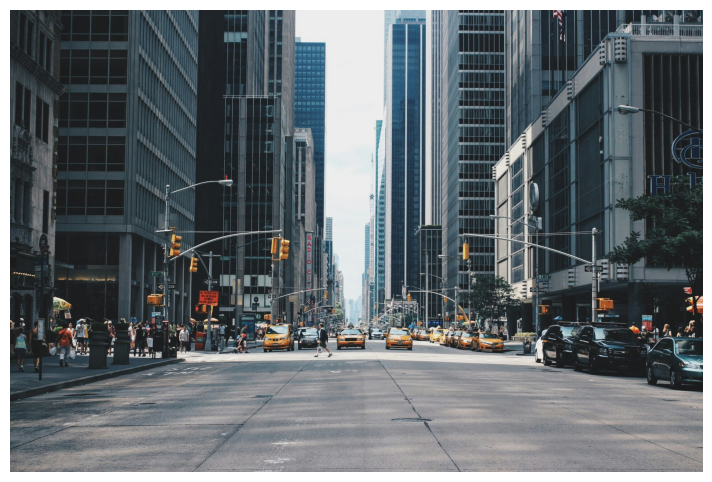

In [7]:
import requests
from PIL import Image
from io import BytesIO

url = "https://images.unsplash.com/photo-1449824913935-59a10b8d2000"

response = requests.get(url)

image = Image.open(
    BytesIO(response.content)
).convert('RGB')

plt.figure(figsize=(10,6))
plt.imshow(image)
plt.axis('off')
plt.show()

In [8]:
input_tensor = transform(image)

input_batch = input_tensor.unsqueeze(0).to(device)

with torch.no_grad():

    output = model(input_batch)['out'][0]

prediction = output.argmax(0)

print(np.unique(
    prediction.cpu().numpy()
))

[ 0  2  7 15]


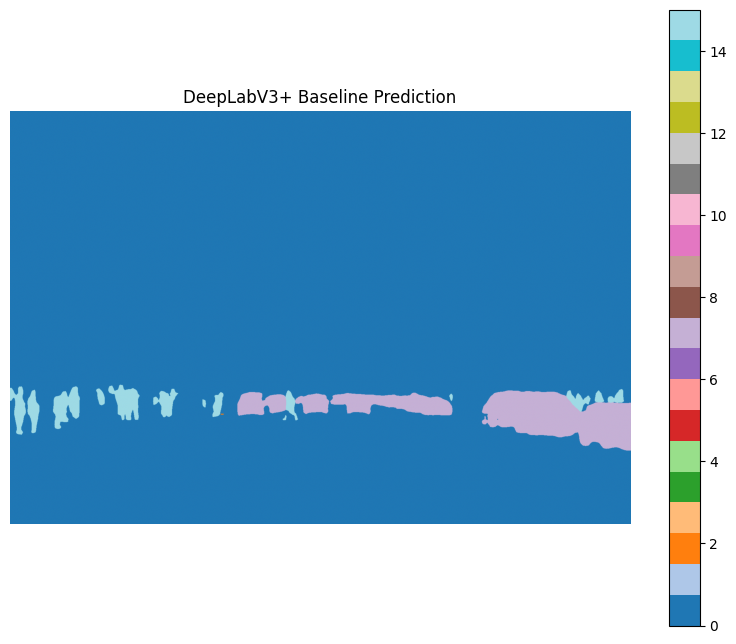

In [9]:
plt.figure(figsize=(10,8))

plt.imshow(
    prediction.cpu().numpy(),
    cmap='tab20'
)

plt.colorbar()

plt.title(
    "DeepLabV3+ Baseline Prediction"
)

plt.axis('off')

plt.show()

In [10]:
pred_np = prediction.cpu().numpy()

print(np.unique(pred_np))

[ 0  2  7 15]


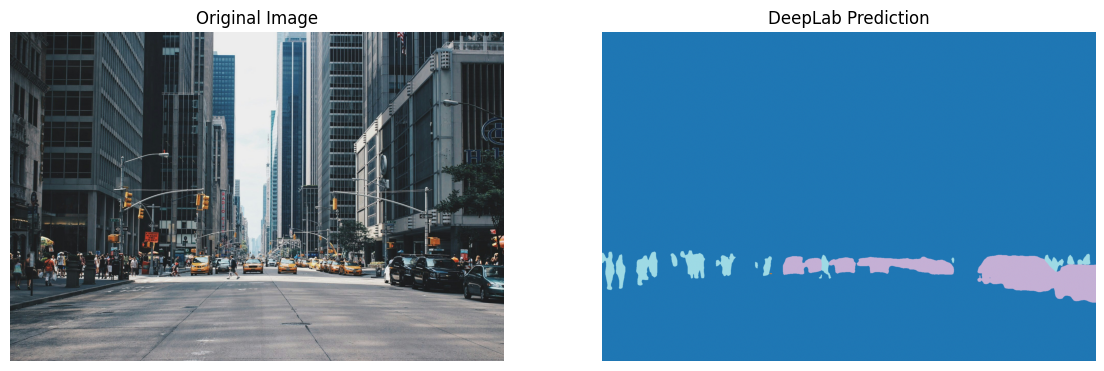

In [11]:
fig, ax = plt.subplots(1,2, figsize=(14,6))

ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(prediction.cpu().numpy(), cmap='tab20')
ax[1].set_title("DeepLab Prediction")
ax[1].axis('off')

plt.show()

In [14]:
scores = torch.softmax(output, dim=0)

print(scores.max())
print(scores.min())

tensor(1., device='cuda:0')
tensor(3.1385e-10, device='cuda:0')
